# Strongest Trend Graphs — Code Version

This notebook keeps the code needed to regenerate the strongest-trend plots, instead of copying the finished images.

I kept the same methods from the original notebooks:
- frequency-domain relative power, centered to each subject's global average
- band-ratio plots, centered to each subject's global average
- same subjects, conditions, ROI/channel settings, bands, and rolling-window method as the original files

Run the cells from top to bottom. The notebook still expects to be run in the same project environment as the original notebooks, where `utils.py` and the EEG data are available.


## BLA — Frequency-domain relative power

In [25]:
# Source: ZBLA_global(1).ipynb, cell 1

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [26]:
# Source: ZBLA_global(1).ipynb, cell 2

# These are the subjects used in your BLA analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLA"

# CHANNELS tells the loader to use the BLA ROI channel group.
CHANNELS = "BLA"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA
Baseline definition: global average over all times and all trials


In [27]:
# Source: ZBLA_global(1).ipynb, cell 3

# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched BLA data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


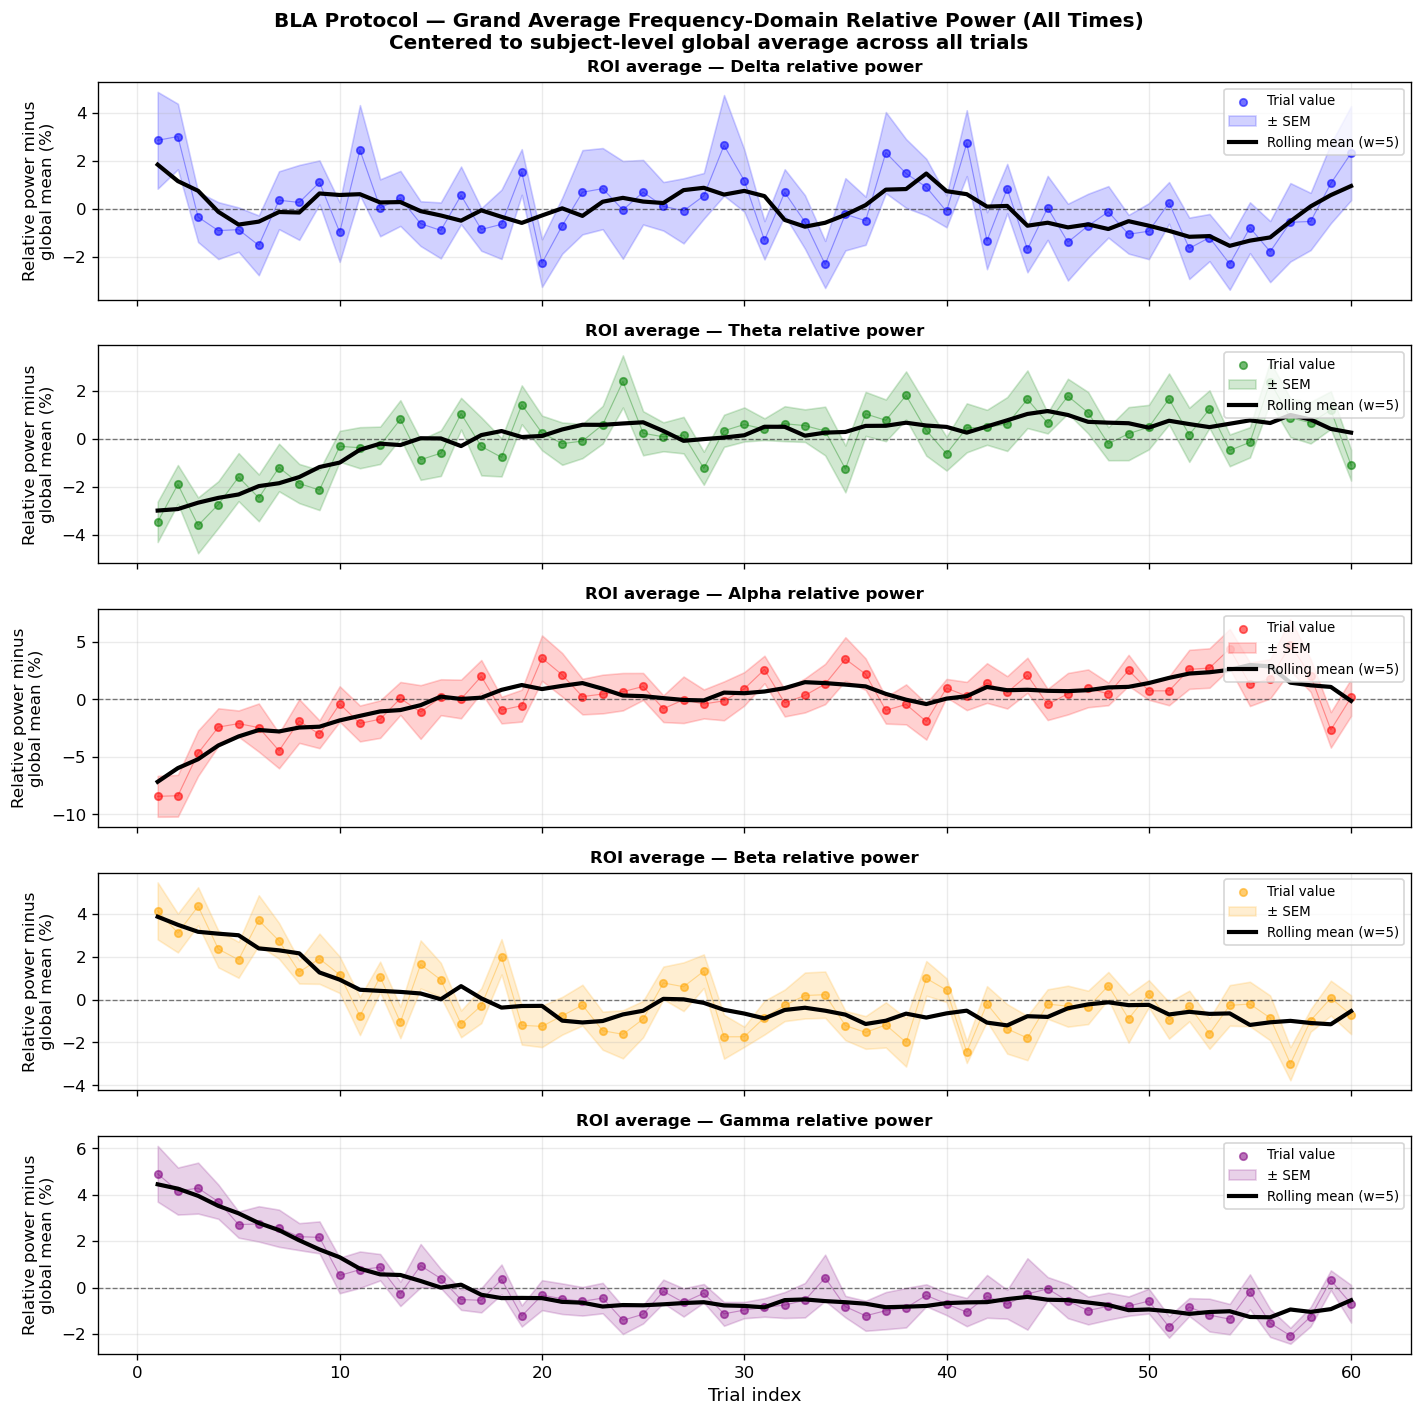

Figure saved: frequency_relative_dynamics_BLA_global_mean_centered.png


In [28]:
# Source: ZBLA_global(1).ipynb, cell 10
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (all times)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# 1) the raw relative power for each trial and band
# 2) the one-row global baseline that gets subtracted
# 3) the centered relative power after subtracting that baseline
all_relative_power_pivots_raw = {}
all_relative_global_baseline_pivots = {}
all_relative_power_pivots_centered = {}

# Loop over each subject that already successfully completed
# the raw frequency-domain absolute-power section above.
for subject_id in processed_subjects:

    # Start from the raw absolute power table:
    # rows = trials
    # columns = bands
    power_pivot_raw = all_power_pivots_raw[subject_id].copy()

    # Force the same band order for every subject so later
    # averaging lines up delta with delta, alpha with alpha, etc.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # For each trial, total power is the sum across all bands.
    # axis=1 means sum across columns within each row.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power into relative power:
    # each band becomes its percentage of that trial's total power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute one subject-level global baseline for each band.
    # This is the mean relative power across all trials for that band.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save the baseline as a one-row DataFrame so you can inspect it later.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Subtract the same baseline value from every trial in that band.
    # After this step:
    #   0  = equal to subject's average relative power for that band
    #   >0 = above average
    #   <0 = below average
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered[subject_id] = relative_power_centered

# These will hold the grand mean and SEM across subjects for each band.
grand_relative_power = {}
grand_relative_sem = {}

# Build one grand-average trial series per band.
for band in bands:

    # Collect one subject vector per band.
    band_trials = []

    for subject_id in processed_subjects:
        relative_pivot = all_relative_power_pivots_centered[subject_id]

        if band in relative_pivot.columns:
            # reset_index(drop=True) makes trial positions line up cleanly
            # when subjects are concatenated side by side.
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power[band] = band_df.mean(axis=1)
        grand_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Plot one subplot per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Trial-by-trial grand mean
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # Uncertainty shading
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling trend line to make the overall direction easier to see
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'BLA Protocol — Grand Average Frequency-Domain Relative Power (All Times)\n'
    'Centered to subject-level global average across all trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_BLA_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_BLA_global_mean_centered.png")


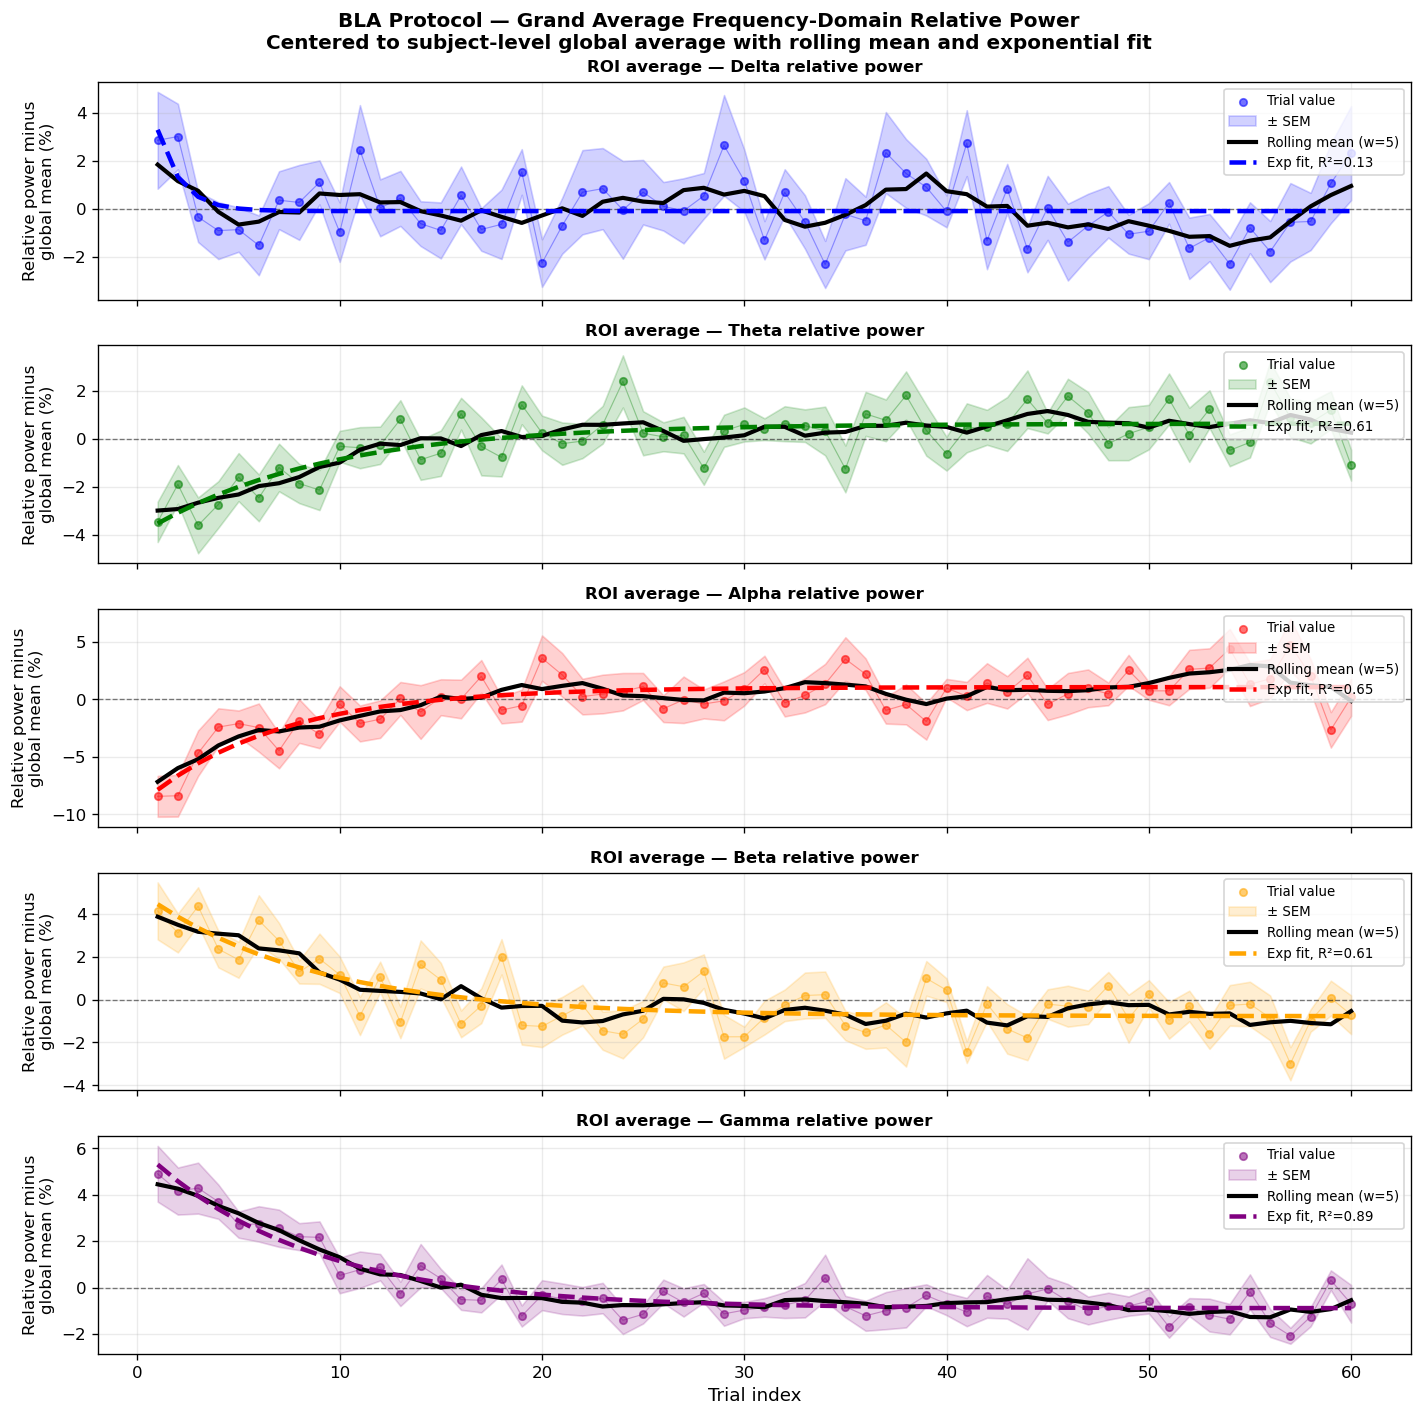

,Band,A,k,C,R squared
0,delta,8.089267,0.868741,-0.097421,0.127228
1,theta,-4.672202,0.114332,0.642217,0.607865
2,alpha,-10.378555,0.149525,1.072369,0.653666
3,beta,5.873869,0.118854,-0.775083,0.614877
4,gamma,7.002730,0.123876,-0.884496,0.893706


Figure saved: frequency_relative_dynamics_BLA_exponential_fits.png


In [30]:
# ------------------------------------------------------------
# EXPONENTIAL DECAY FITS FOR ALL FREQUENCY BANDS
# Keeps rolling mean in black and adds a unique dashed fit line
# ------------------------------------------------------------

from scipy.optimize import curve_fit

# Exponential decay model:
# A = starting height above/below plateau
# k = decay rate
# C = plateau/asymptote
def exp_decay(x, A, k, C):
    return A * np.exp(-k * x) + C

# Store fit results for each band
exp_fit_results = []

# Plot one subplot per band
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # ------------------------------------------------------------
        # Original trial-by-trial grand mean
        # ------------------------------------------------------------

        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label="Trial value"
        )

        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        # ------------------------------------------------------------
        # SEM shading
        # ------------------------------------------------------------

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label="± SEM"
        )

        # ------------------------------------------------------------
        # Rolling mean line — keep this black
        # ------------------------------------------------------------

        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color="black",
            linewidth=2.5,
            zorder=3,
            label=f"Rolling mean (w={ROLLING_WINDOW})"
        )

        # ------------------------------------------------------------
        # Exponential fit line — unique looking line
        # ------------------------------------------------------------

        try:
            # Starting guesses
            A_guess = values[0] - values[-1]
            k_guess = 0.10
            C_guess = values[-1]

            initial_guess = [A_guess, k_guess, C_guess]

            # Fit exponential curve
            params, covariance = curve_fit(
                exp_decay,
                trial_idx,
                values,
                p0=initial_guess,
                maxfev=10000
            )

            A_fit, k_fit, C_fit = params

            # Predicted values from fit
            fitted_values = exp_decay(trial_idx, A_fit, k_fit, C_fit)

            # R squared
            ss_res = np.sum((values - fitted_values) ** 2)
            ss_tot = np.sum((values - np.mean(values)) ** 2)
            r_squared = 1 - (ss_res / ss_tot)

            # Plot the exponential fit as a unique dashed line
            ax.plot(
                trial_idx,
                fitted_values,
                color=color,
                linewidth=2.7,
                linestyle="--",
                zorder=4,
                label=f"Exp fit, R²={r_squared:.2f}"
            )

            # Save fit results
            exp_fit_results.append({
                "Band": band,
                "A": A_fit,
                "k": k_fit,
                "C": C_fit,
                "R squared": r_squared
            })

        except RuntimeError:
            print(f"Could not fit exponential curve for {band}.")

            exp_fit_results.append({
                "Band": band,
                "A": np.nan,
                "k": np.nan,
                "C": np.nan,
                "R squared": np.nan
            })

    ax.set_ylabel("Relative power minus\nglobal mean (%)", fontsize=10)
    ax.set_title(
        f"ROI average — {band.capitalize()} relative power",
        fontsize=10,
        fontweight="bold"
    )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--",
        alpha=0.5
    )

    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Trial index", fontsize=11)

fig.suptitle(
    "BLA Protocol — Grand Average Frequency-Domain Relative Power\n"
    "Centered to subject-level global average with rolling mean and exponential fit",
    fontsize=12,
    fontweight="bold"
)

fig.tight_layout()

plt.savefig(
    "frequency_relative_dynamics_BLA_exponential_fits.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

# ------------------------------------------------------------
# Display fit results as a table
# ------------------------------------------------------------

exp_fit_results_df = pd.DataFrame(exp_fit_results)

display(exp_fit_results_df)

print("Figure saved: frequency_relative_dynamics_BLA_exponential_fits.png")

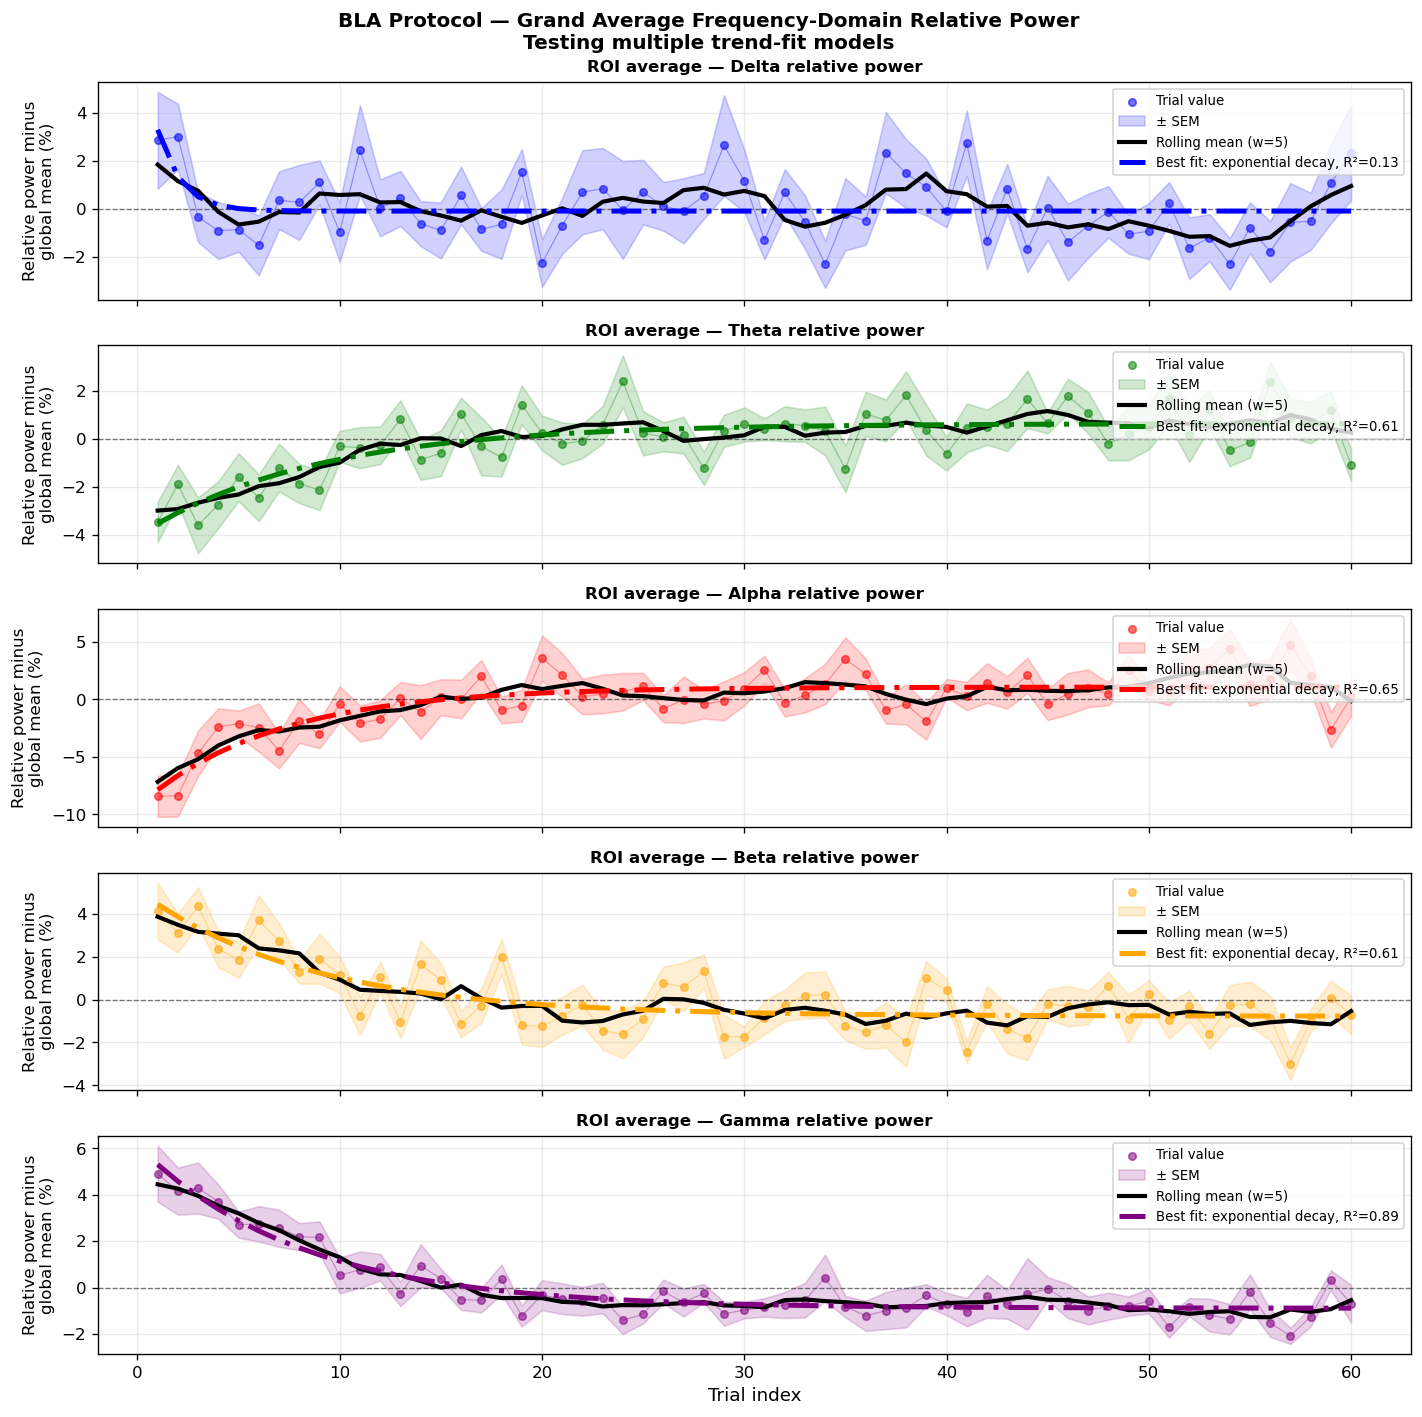

,Band,Fit type,R squared,RMSE,AIC,Best by AIC
15,alpha,exponential decay,0.653666,1.455836,51.069648,True
16,alpha,logarithmic,0.618358,1.528245,54.894431,False
14,alpha,cubic,0.623104,1.518713,58.143592,False
17,alpha,inverse,0.558311,1.644080,65.661706,False
13,alpha,quadratic,0.542480,1.673285,67.774653,False
12,alpha,linear,0.391450,1.929802,82.890115,False
21,beta,exponential decay,0.614877,0.982827,3.921335,True
20,beta,cubic,0.618413,0.978304,5.367856,False
22,beta,logarithmic,0.559460,1.051164,9.987735,False
19,beta,quadratic,0.551674,1.060411,13.038842,False


Figure saved: frequency_relative_dynamics_BLA_multiple_fit_tests.png


In [31]:
# ------------------------------------------------------------
# TEST MULTIPLE FIT TYPES FOR ALL FREQUENCY BANDS
# Keeps rolling mean in black and plots the best-fit curve
# ------------------------------------------------------------

from scipy.optimize import curve_fit
import warnings

# ------------------------------------------------------------
# Helper functions for different fit types
# ------------------------------------------------------------

def linear_model(x, a, b):
    return a * x + b

def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c

def cubic_model(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exp_decay_model(x, A, k, C):
    return A * np.exp(-k * x) + C

def log_model(x, a, b):
    return a * np.log(x) + b

def inverse_model(x, a, b, c):
    return a / x + b + c * x * 0


# ------------------------------------------------------------
# Helper function to score each fit
# ------------------------------------------------------------

def calculate_fit_stats(y_true, y_pred, num_params):
    residuals = y_true - y_pred

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r_squared = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean(residuals**2))

    n = len(y_true)

    # AIC penalizes overly complicated models.
    # Lower AIC = better balance of fit quality and simplicity.
    if ss_res <= 0:
        aic = np.nan
    else:
        aic = n * np.log(ss_res / n) + 2 * num_params

    return r_squared, rmse, aic


# ------------------------------------------------------------
# Try multiple models on one band
# ------------------------------------------------------------

def test_fit_models(trial_idx, values):
    fit_results = []

    # -------------------------
    # Linear fit
    # -------------------------
    try:
        params, _ = curve_fit(
            linear_model,
            trial_idx,
            values,
            maxfev=10000
        )

        fitted = linear_model(trial_idx, *params)
        r2, rmse, aic = calculate_fit_stats(values, fitted, len(params))

        fit_results.append({
            "Fit type": "linear",
            "params": params,
            "fitted": fitted,
            "R squared": r2,
            "RMSE": rmse,
            "AIC": aic
        })

    except Exception:
        pass

    # -------------------------
    # Quadratic fit
    # -------------------------
    try:
        params, _ = curve_fit(
            quadratic_model,
            trial_idx,
            values,
            maxfev=10000
        )

        fitted = quadratic_model(trial_idx, *params)
        r2, rmse, aic = calculate_fit_stats(values, fitted, len(params))

        fit_results.append({
            "Fit type": "quadratic",
            "params": params,
            "fitted": fitted,
            "R squared": r2,
            "RMSE": rmse,
            "AIC": aic
        })

    except Exception:
        pass

    # -------------------------
    # Cubic fit
    # -------------------------
    try:
        params, _ = curve_fit(
            cubic_model,
            trial_idx,
            values,
            maxfev=10000
        )

        fitted = cubic_model(trial_idx, *params)
        r2, rmse, aic = calculate_fit_stats(values, fitted, len(params))

        fit_results.append({
            "Fit type": "cubic",
            "params": params,
            "fitted": fitted,
            "R squared": r2,
            "RMSE": rmse,
            "AIC": aic
        })

    except Exception:
        pass

    # -------------------------
    # Exponential decay fit
    # -------------------------
    try:
        A_guess = values[0] - values[-1]
        k_guess = 0.10
        C_guess = values[-1]

        params, _ = curve_fit(
            exp_decay_model,
            trial_idx,
            values,
            p0=[A_guess, k_guess, C_guess],
            maxfev=10000
        )

        fitted = exp_decay_model(trial_idx, *params)
        r2, rmse, aic = calculate_fit_stats(values, fitted, len(params))

        fit_results.append({
            "Fit type": "exponential decay",
            "params": params,
            "fitted": fitted,
            "R squared": r2,
            "RMSE": rmse,
            "AIC": aic
        })

    except Exception:
        pass

    # -------------------------
    # Logarithmic fit
    # -------------------------
    try:
        params, _ = curve_fit(
            log_model,
            trial_idx,
            values,
            maxfev=10000
        )

        fitted = log_model(trial_idx, *params)
        r2, rmse, aic = calculate_fit_stats(values, fitted, len(params))

        fit_results.append({
            "Fit type": "logarithmic",
            "params": params,
            "fitted": fitted,
            "R squared": r2,
            "RMSE": rmse,
            "AIC": aic
        })

    except Exception:
        pass

    # -------------------------
    # Inverse fit
    # -------------------------
    try:
        params, _ = curve_fit(
            inverse_model,
            trial_idx,
            values,
            maxfev=10000
        )

        fitted = inverse_model(trial_idx, *params)
        r2, rmse, aic = calculate_fit_stats(values, fitted, len(params))

        fit_results.append({
            "Fit type": "inverse",
            "params": params,
            "fitted": fitted,
            "R squared": r2,
            "RMSE": rmse,
            "AIC": aic
        })

    except Exception:
        pass

    return fit_results


# ------------------------------------------------------------
# Run fits for all bands and plot best one on each graph
# ------------------------------------------------------------

all_fit_results = []
best_fit_by_band = {}

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for i, (band, color) in enumerate(zip(bands, colors)):
        ax = axes[i]

        if band in grand_relative_power:
            values = grand_relative_power[band].values
            errors = grand_relative_sem[band].values
            trial_idx = np.arange(1, len(values) + 1)

            # ------------------------------------------------------------
            # Original trial-by-trial data
            # ------------------------------------------------------------

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label="Trial value"
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label="± SEM"
            )

            # ------------------------------------------------------------
            # Rolling mean in black
            # ------------------------------------------------------------

            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color="black",
                linewidth=2.5,
                zorder=3,
                label=f"Rolling mean (w={ROLLING_WINDOW})"
            )

            # ------------------------------------------------------------
            # Test all fits
            # ------------------------------------------------------------

            fit_results = test_fit_models(trial_idx, values)

            if len(fit_results) > 0:

                # Choose the best fit using AIC.
                # Lower AIC is better because it rewards good fit
                # while penalizing overly complicated curves.
                best_fit = min(fit_results, key=lambda result: result["AIC"])

                best_fit_by_band[band] = best_fit

                # Save all results for table
                for result in fit_results:
                    all_fit_results.append({
                        "Band": band,
                        "Fit type": result["Fit type"],
                        "R squared": result["R squared"],
                        "RMSE": result["RMSE"],
                        "AIC": result["AIC"],
                        "Best by AIC": result["Fit type"] == best_fit["Fit type"]
                    })

                # Plot best fit as unique-looking line
                ax.plot(
                    trial_idx,
                    best_fit["fitted"],
                    color=color,
                    linewidth=3,
                    linestyle=(0, (6, 2, 1, 2)),
                    zorder=4,
                    label=f"Best fit: {best_fit['Fit type']}, R²={best_fit['R squared']:.2f}"
                )

        ax.set_ylabel("Relative power minus\nglobal mean (%)", fontsize=10)

        ax.set_title(
            f"ROI average — {band.capitalize()} relative power",
            fontsize=10,
            fontweight="bold"
        )

        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
            linestyle="--",
            alpha=0.5
        )

        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Trial index", fontsize=11)

fig.suptitle(
    "BLA Protocol — Grand Average Frequency-Domain Relative Power\n"
    "Testing multiple trend-fit models",
    fontsize=12,
    fontweight="bold"
)

fig.tight_layout()

plt.savefig(
    "frequency_relative_dynamics_BLA_multiple_fit_tests.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# Display table of all fit results
# ------------------------------------------------------------

fit_results_df = pd.DataFrame(all_fit_results)

# Sort so the best model for each band appears first
fit_results_df = fit_results_df.sort_values(
    by=["Band", "AIC"],
    ascending=[True, True]
)

display(fit_results_df)

print("Figure saved: frequency_relative_dynamics_BLA_multiple_fit_tests.png")

## BLA — Band ratios

In [5]:
# Source: ZBLA_ratio(1).ipynb, cell 2

# These are the subjects used in your BLA analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLA"

# CHANNELS tells the loader to use the BLA ROI channel group.
CHANNELS = "BLA"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [6]:
# Source: ZBLA_ratio(1).ipynb, cell 3

# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same BLA epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.

    Parameters
    ----------
    results : dict
        Output from compute_centered_band_ratios_for_window().

    title_label : str
        Label used in the graph title, such as "All Times" or "0–500 ms".

    save_filename : str
        Name of the saved PNG file.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    # This forces it to act like a list so the loop below still works.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'BLA Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")


all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


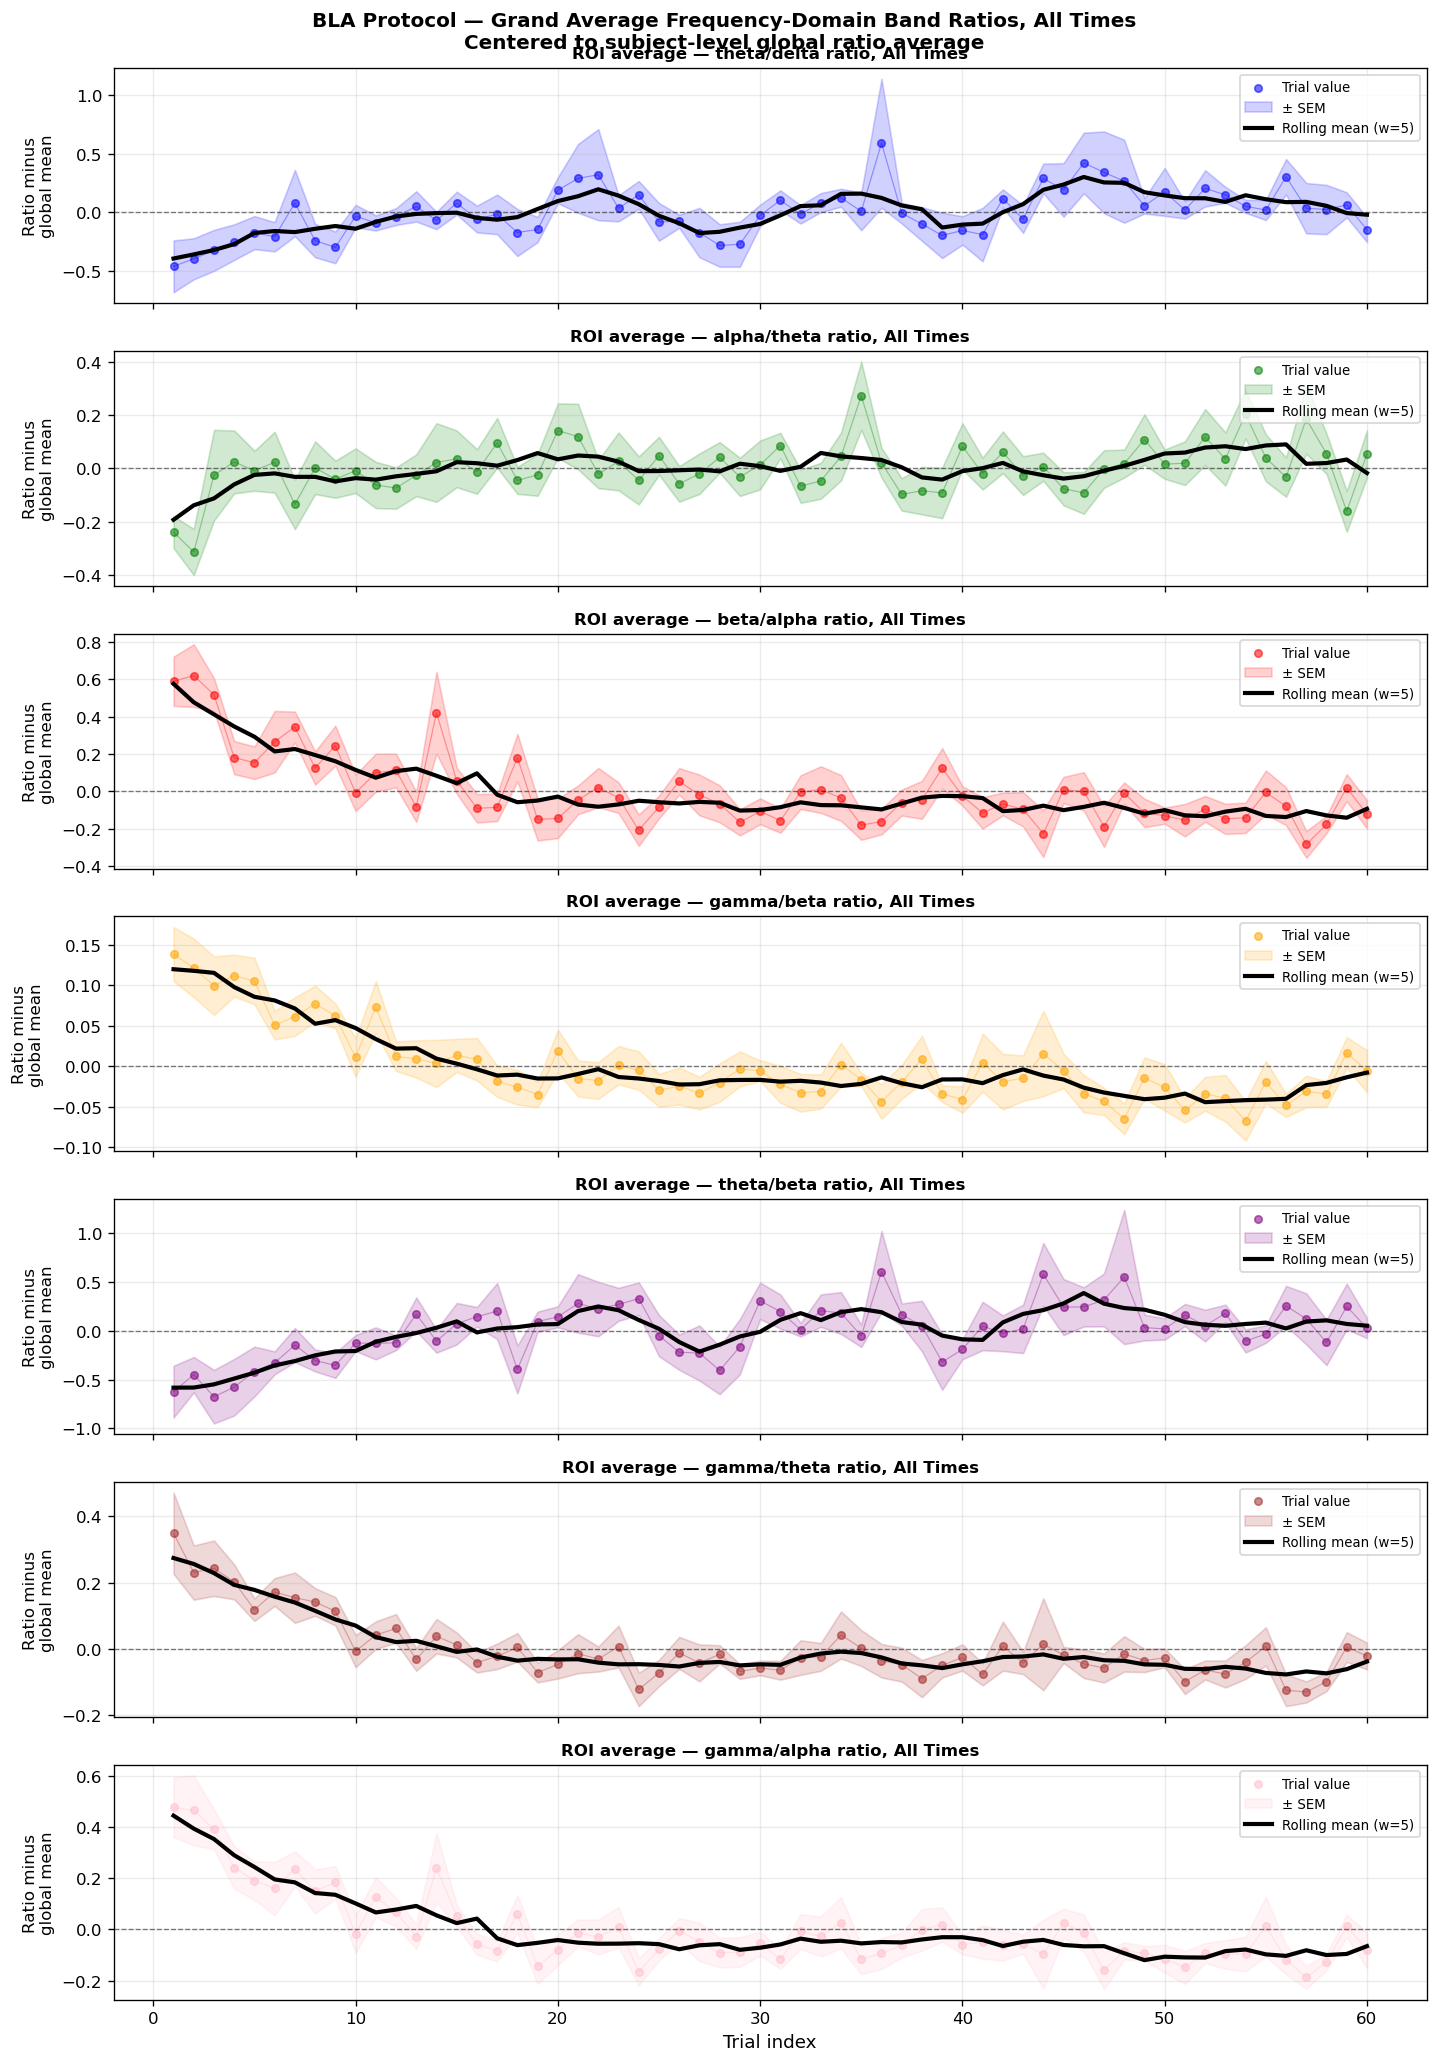

Figure saved: BLA_band_ratios_all_times_global_mean_centered.png


In [7]:
# Source: ZBLA_ratio(1).ipynb, cell 4

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="BLA_band_ratios_all_times_global_mean_centered.png"
)


## BLT — Frequency-domain relative power

In [8]:
# Source: ZBLT_global(3).ipynb, cell 1

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [9]:
# Source: ZBLT_global(3).ipynb, cell 2

# These are the subjects used in your BLT analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLT"

# CHANNELS tells the loader to use the BLT ROI channel group.
CHANNELS = "BLT"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLT
Channels: BLT
Baseline definition: global average over all times and all trials


In [10]:
# Source: ZBLT_global(3).ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched BLT data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


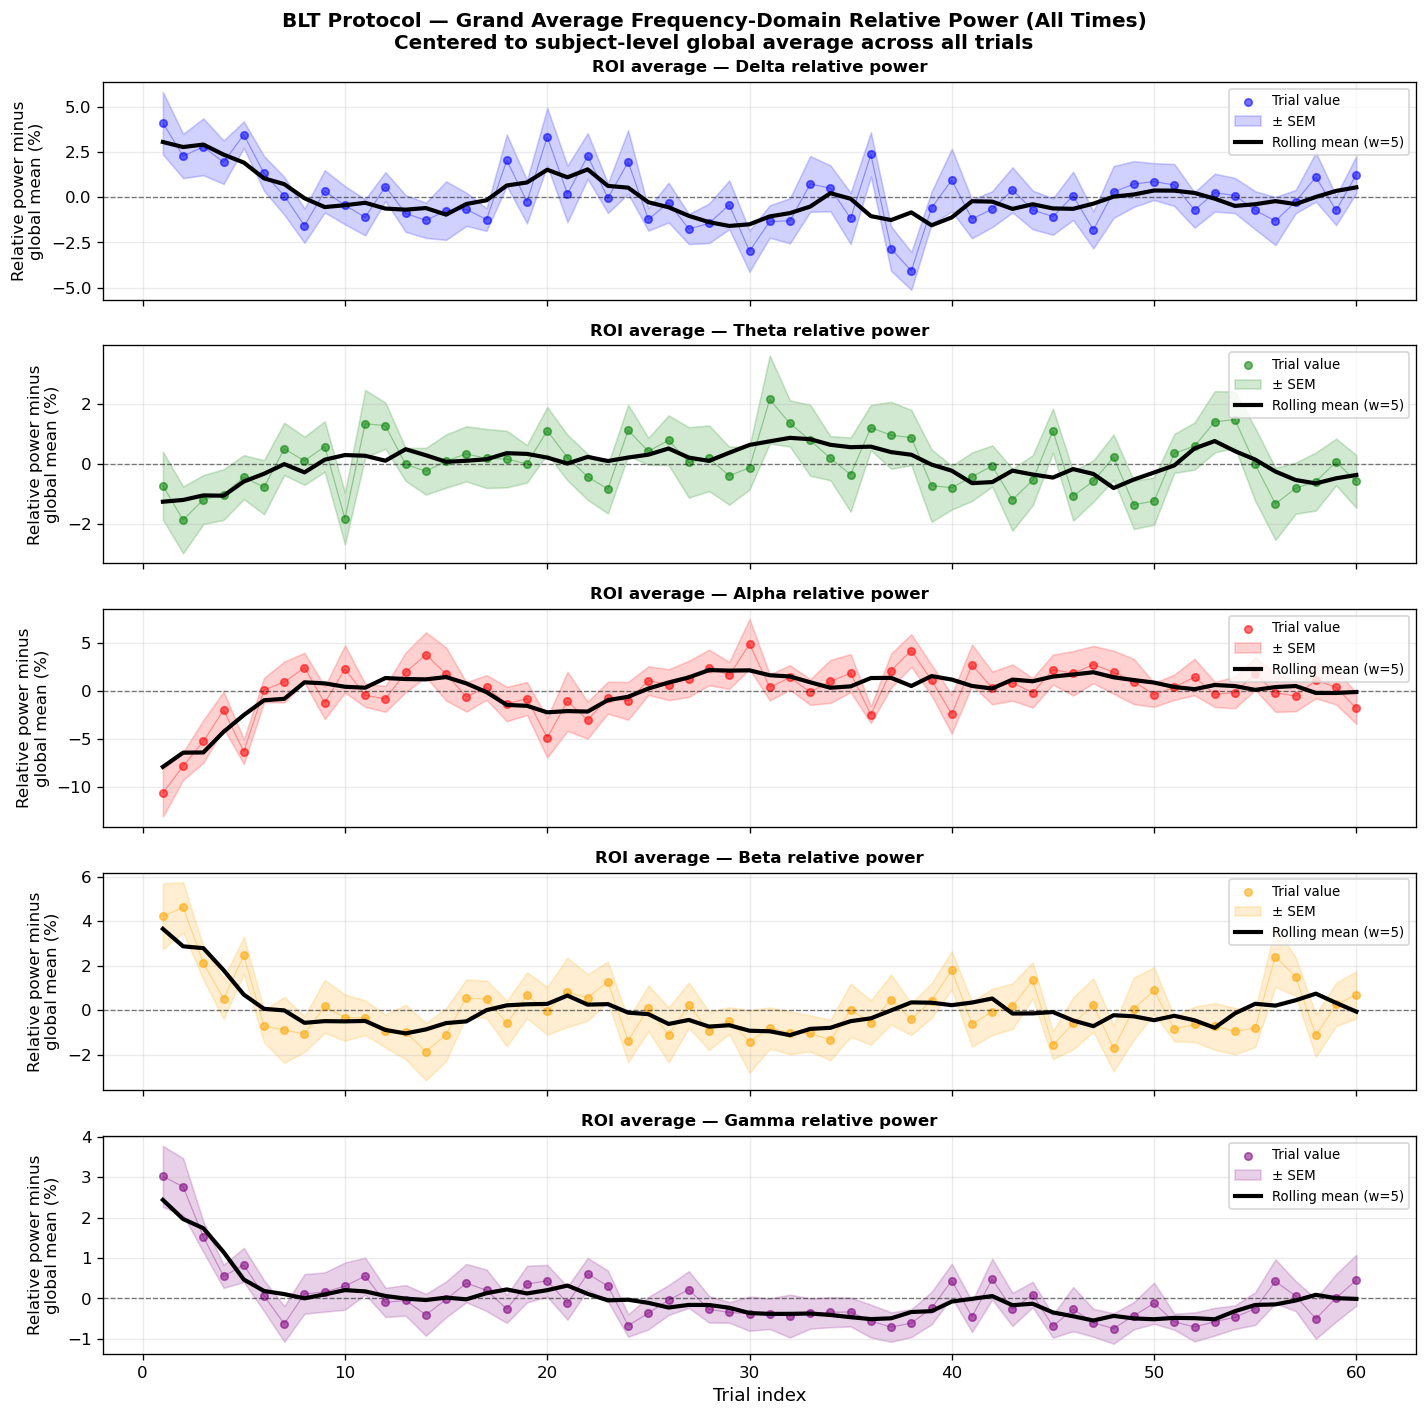

Figure saved: frequency_relative_dynamics_BLT_global_mean_centered.png


In [11]:
# Source: ZBLT_global(3).ipynb, cell 11
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (all times)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# 1) the raw relative power for each trial and band
# 2) the one-row global baseline that gets subtracted
# 3) the centered relative power after subtracting that baseline
all_relative_power_pivots_raw = {}
all_relative_global_baseline_pivots = {}
all_relative_power_pivots_centered = {}

# Loop over each subject that already successfully completed
# the raw frequency-domain absolute-power section above.
for subject_id in processed_subjects:

    # Start from the raw absolute power table:
    # rows = trials
    # columns = bands
    power_pivot_raw = all_power_pivots_raw[subject_id].copy()

    # Force the same band order for every subject so later
    # averaging lines up delta with delta, alpha with alpha, etc.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # For each trial, total power is the sum across all bands.
    # axis=1 means sum across columns within each row.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power into relative power:
    # each band becomes its percentage of that trial's total power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute one subject-level global baseline for each band.
    # This is the mean relative power across all trials for that band.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save the baseline as a one-row DataFrame so you can inspect it later.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Subtract the same baseline value from every trial in that band.
    # After this step:
    #   0  = equal to subject's average relative power for that band
    #   >0 = above average
    #   <0 = below average
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered[subject_id] = relative_power_centered

# These will hold the grand mean and SEM across subjects for each band.
grand_relative_power = {}
grand_relative_sem = {}

# Build one grand-average trial series per band.
for band in bands:

    # Collect one subject vector per band.
    band_trials = []

    for subject_id in processed_subjects:
        relative_pivot = all_relative_power_pivots_centered[subject_id]

        if band in relative_pivot.columns:
            # reset_index(drop=True) makes trial positions line up cleanly
            # when subjects are concatenated side by side.
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power[band] = band_df.mean(axis=1)
        grand_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Plot one subplot per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Trial-by-trial grand mean
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # Uncertainty shading
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling trend line to make the overall direction easier to see
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'BLT Protocol — Grand Average Frequency-Domain Relative Power (All Times)\n'
    'Centered to subject-level global average across all trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_BLT_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_BLT_global_mean_centered.png")


## BLT — Band ratios

In [12]:
# Source: ZBLT_ratio(3).ipynb, cell 2

# These are the subjects used in your BLT analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLT"

# CHANNELS tells the loader to use the BLT ROI channel group.
CHANNELS = "BLT"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLT
Channels: BLT
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [13]:
# Source: ZBLT_ratio(3).ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same BLT epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.

    Parameters
    ----------
    results : dict
        Output from compute_centered_band_ratios_for_window().

    title_label : str
        Label used in the graph title, such as "All Times" or "0–500 ms".

    save_filename : str
        Name of the saved PNG file.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    # This forces it to act like a list so the loop below still works.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'BLT Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")


all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


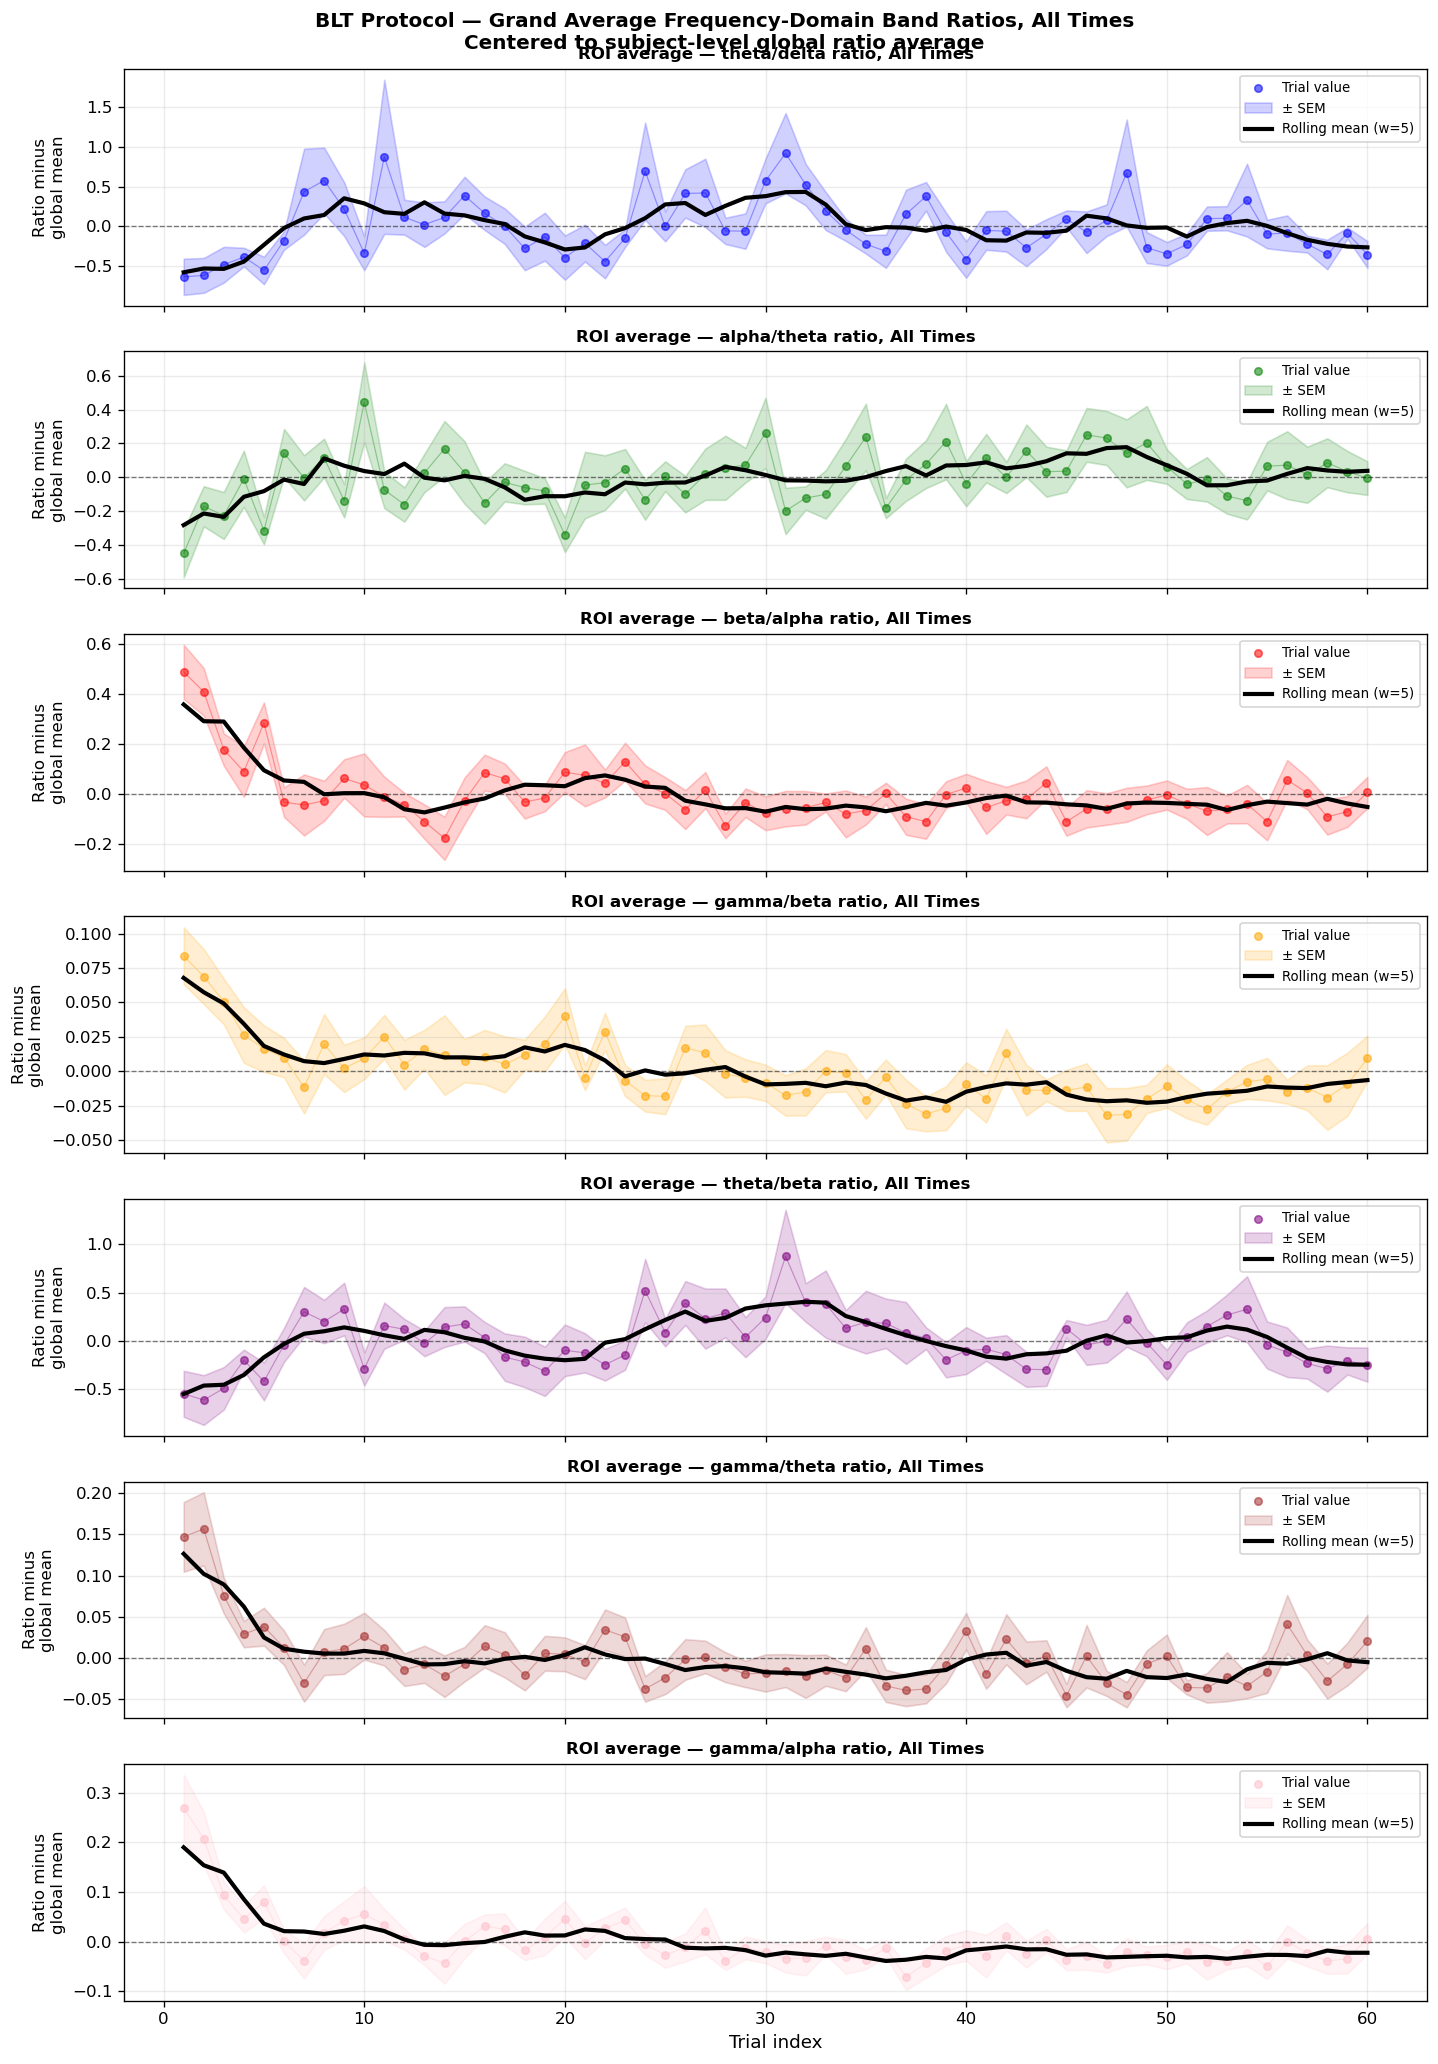

Figure saved: BLT_band_ratios_all_times_global_mean_centered.png


In [14]:
# Source: ZBLT_ratio(3).ipynb, cell 4

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="BLT_band_ratios_all_times_global_mean_centered.png"
)


## CISI — Frequency-domain relative power

In [15]:
# Source: ZCISI_global.ipynb, cell 1

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [16]:
# Source: ZCISI_global.ipynb, cell 2

# These are the subjects used in your CISI analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
# For CISI, the working notebook loads the data using the P1 condition label.
CONDITION = "P1"

# CHANNELS tells the loader which ROI channel group to use.
# For CISI, the working notebook also uses the P1 channel label.
CHANNELS = "P1"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: P1
Channels: P1
Baseline definition: global average over all times and all trials


In [17]:
# Source: ZCISI_global.ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched CISI data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


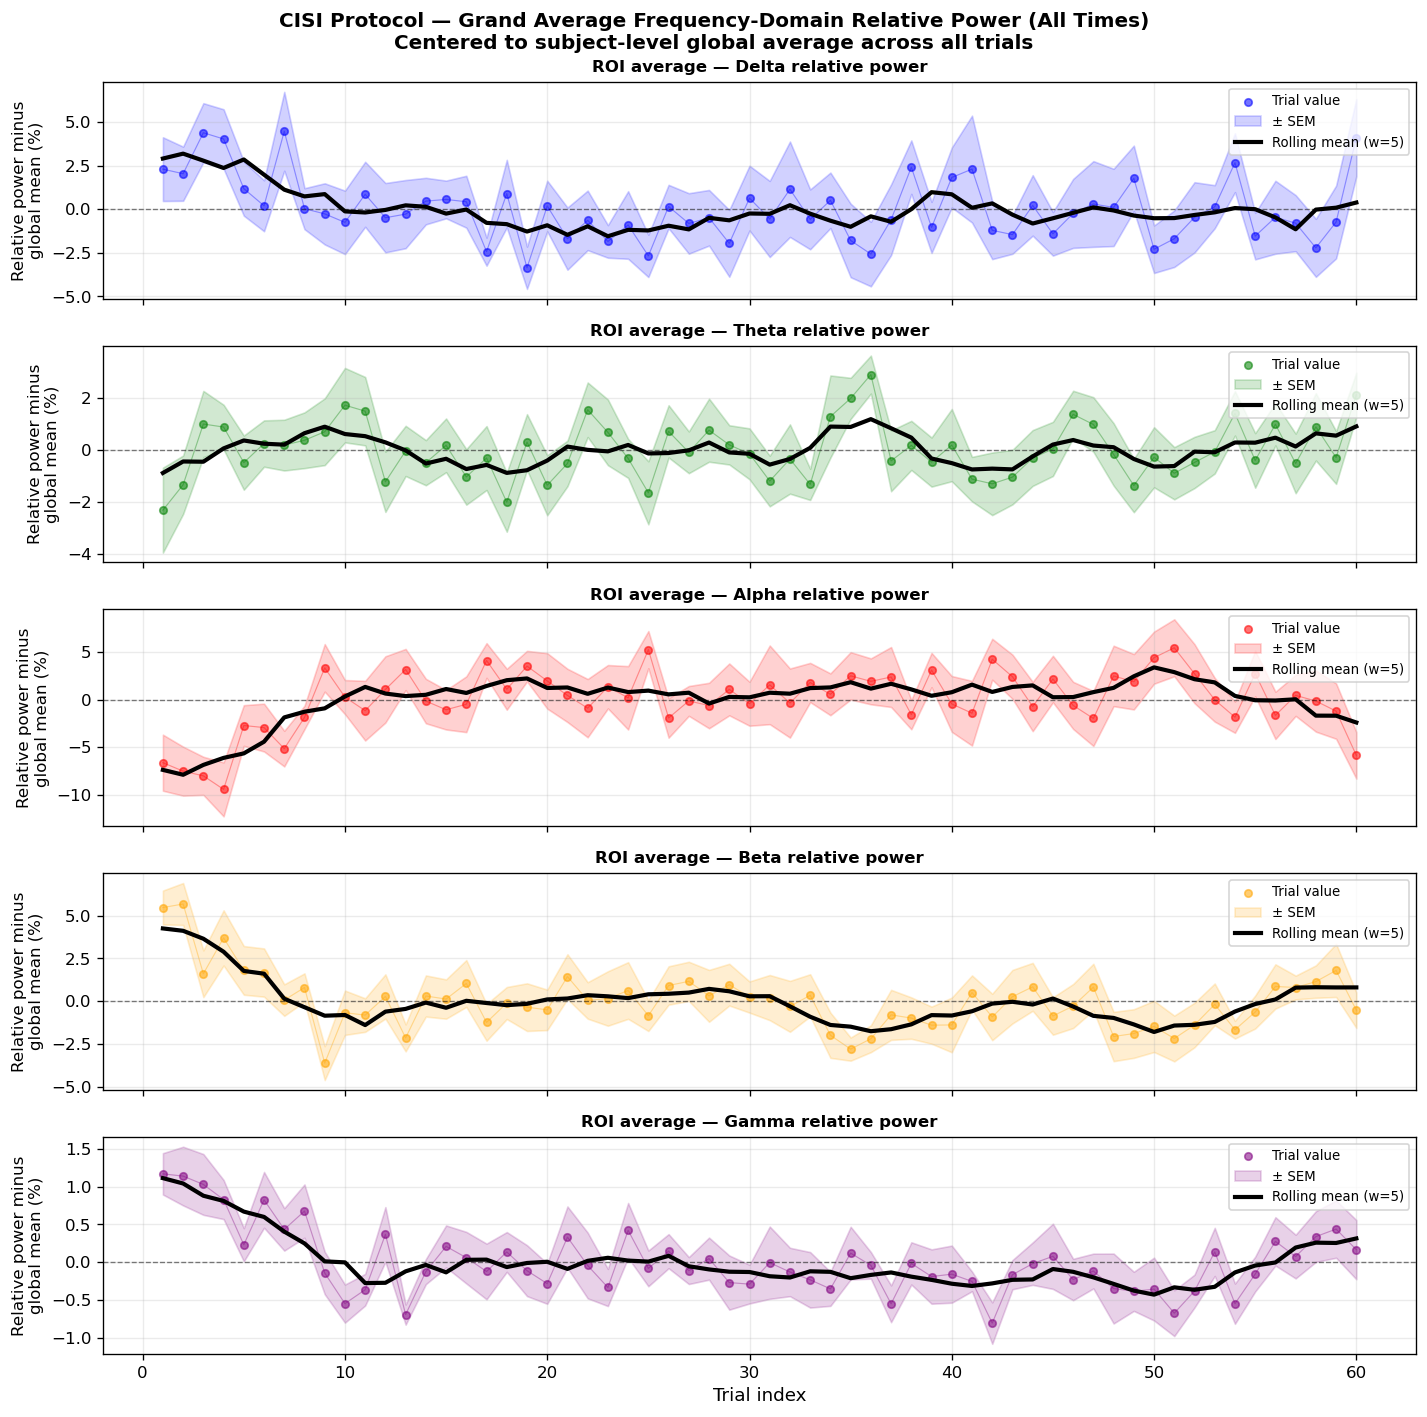

Figure saved: frequency_relative_dynamics_CISI_global_mean_centered.png


In [18]:
# Source: ZCISI_global.ipynb, cell 11
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (all times)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# 1) the raw relative power for each trial and band
# 2) the one-row global baseline that gets subtracted
# 3) the centered relative power after subtracting that baseline
all_relative_power_pivots_raw = {}
all_relative_global_baseline_pivots = {}
all_relative_power_pivots_centered = {}

# Loop over each subject that already successfully completed
# the raw frequency-domain absolute-power section above.
for subject_id in processed_subjects:

    # Start from the raw absolute power table:
    # rows = trials
    # columns = bands
    power_pivot_raw = all_power_pivots_raw[subject_id].copy()

    # Force the same band order for every subject so later
    # averaging lines up delta with delta, alpha with alpha, etc.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # For each trial, total power is the sum across all bands.
    # axis=1 means sum across columns within each row.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power into relative power:
    # each band becomes its percentage of that trial's total power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute one subject-level global baseline for each band.
    # This is the mean relative power across all trials for that band.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save the baseline as a one-row DataFrame so you can inspect it later.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Subtract the same baseline value from every trial in that band.
    # After this step:
    #   0  = equal to subject's average relative power for that band
    #   >0 = above average
    #   <0 = below average
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered[subject_id] = relative_power_centered

# These will hold the grand mean and SEM across subjects for each band.
grand_relative_power = {}
grand_relative_sem = {}

# Build one grand-average trial series per band.
for band in bands:

    # Collect one subject vector per band.
    band_trials = []

    for subject_id in processed_subjects:
        relative_pivot = all_relative_power_pivots_centered[subject_id]

        if band in relative_pivot.columns:
            # reset_index(drop=True) makes trial positions line up cleanly
            # when subjects are concatenated side by side.
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power[band] = band_df.mean(axis=1)
        grand_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Plot one subplot per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Trial-by-trial grand mean
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # Uncertainty shading
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling trend line to make the overall direction easier to see
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Relative Power (All Times)\n'
    'Centered to subject-level global average across all trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_CISI_global_mean_centered.png")


## CISI — Band ratios

In [19]:
# Source: ZCISI_ratio.ipynb, cell 2

# These are the subjects used in your CISI analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
# For CISI, the working notebook loads the data using the P1 condition label.
CONDITION = "P1"

# CHANNELS tells the loader which ROI channel group to use.
# For CISI, the working notebook also uses the P1 channel label.
CHANNELS = "P1"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: P1
Channels: P1
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [20]:
# Source: ZCISI_ratio.ipynb, cell 3
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same CISI/P1 epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.

    Parameters
    ----------
    results : dict
        Output from compute_centered_band_ratios_for_window().

    title_label : str
        Label used in the graph title, such as "All Times" or "0–500 ms".

    save_filename : str
        Name of the saved PNG file.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    # This forces it to act like a list so the loop below still works.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'CISI Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")


all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


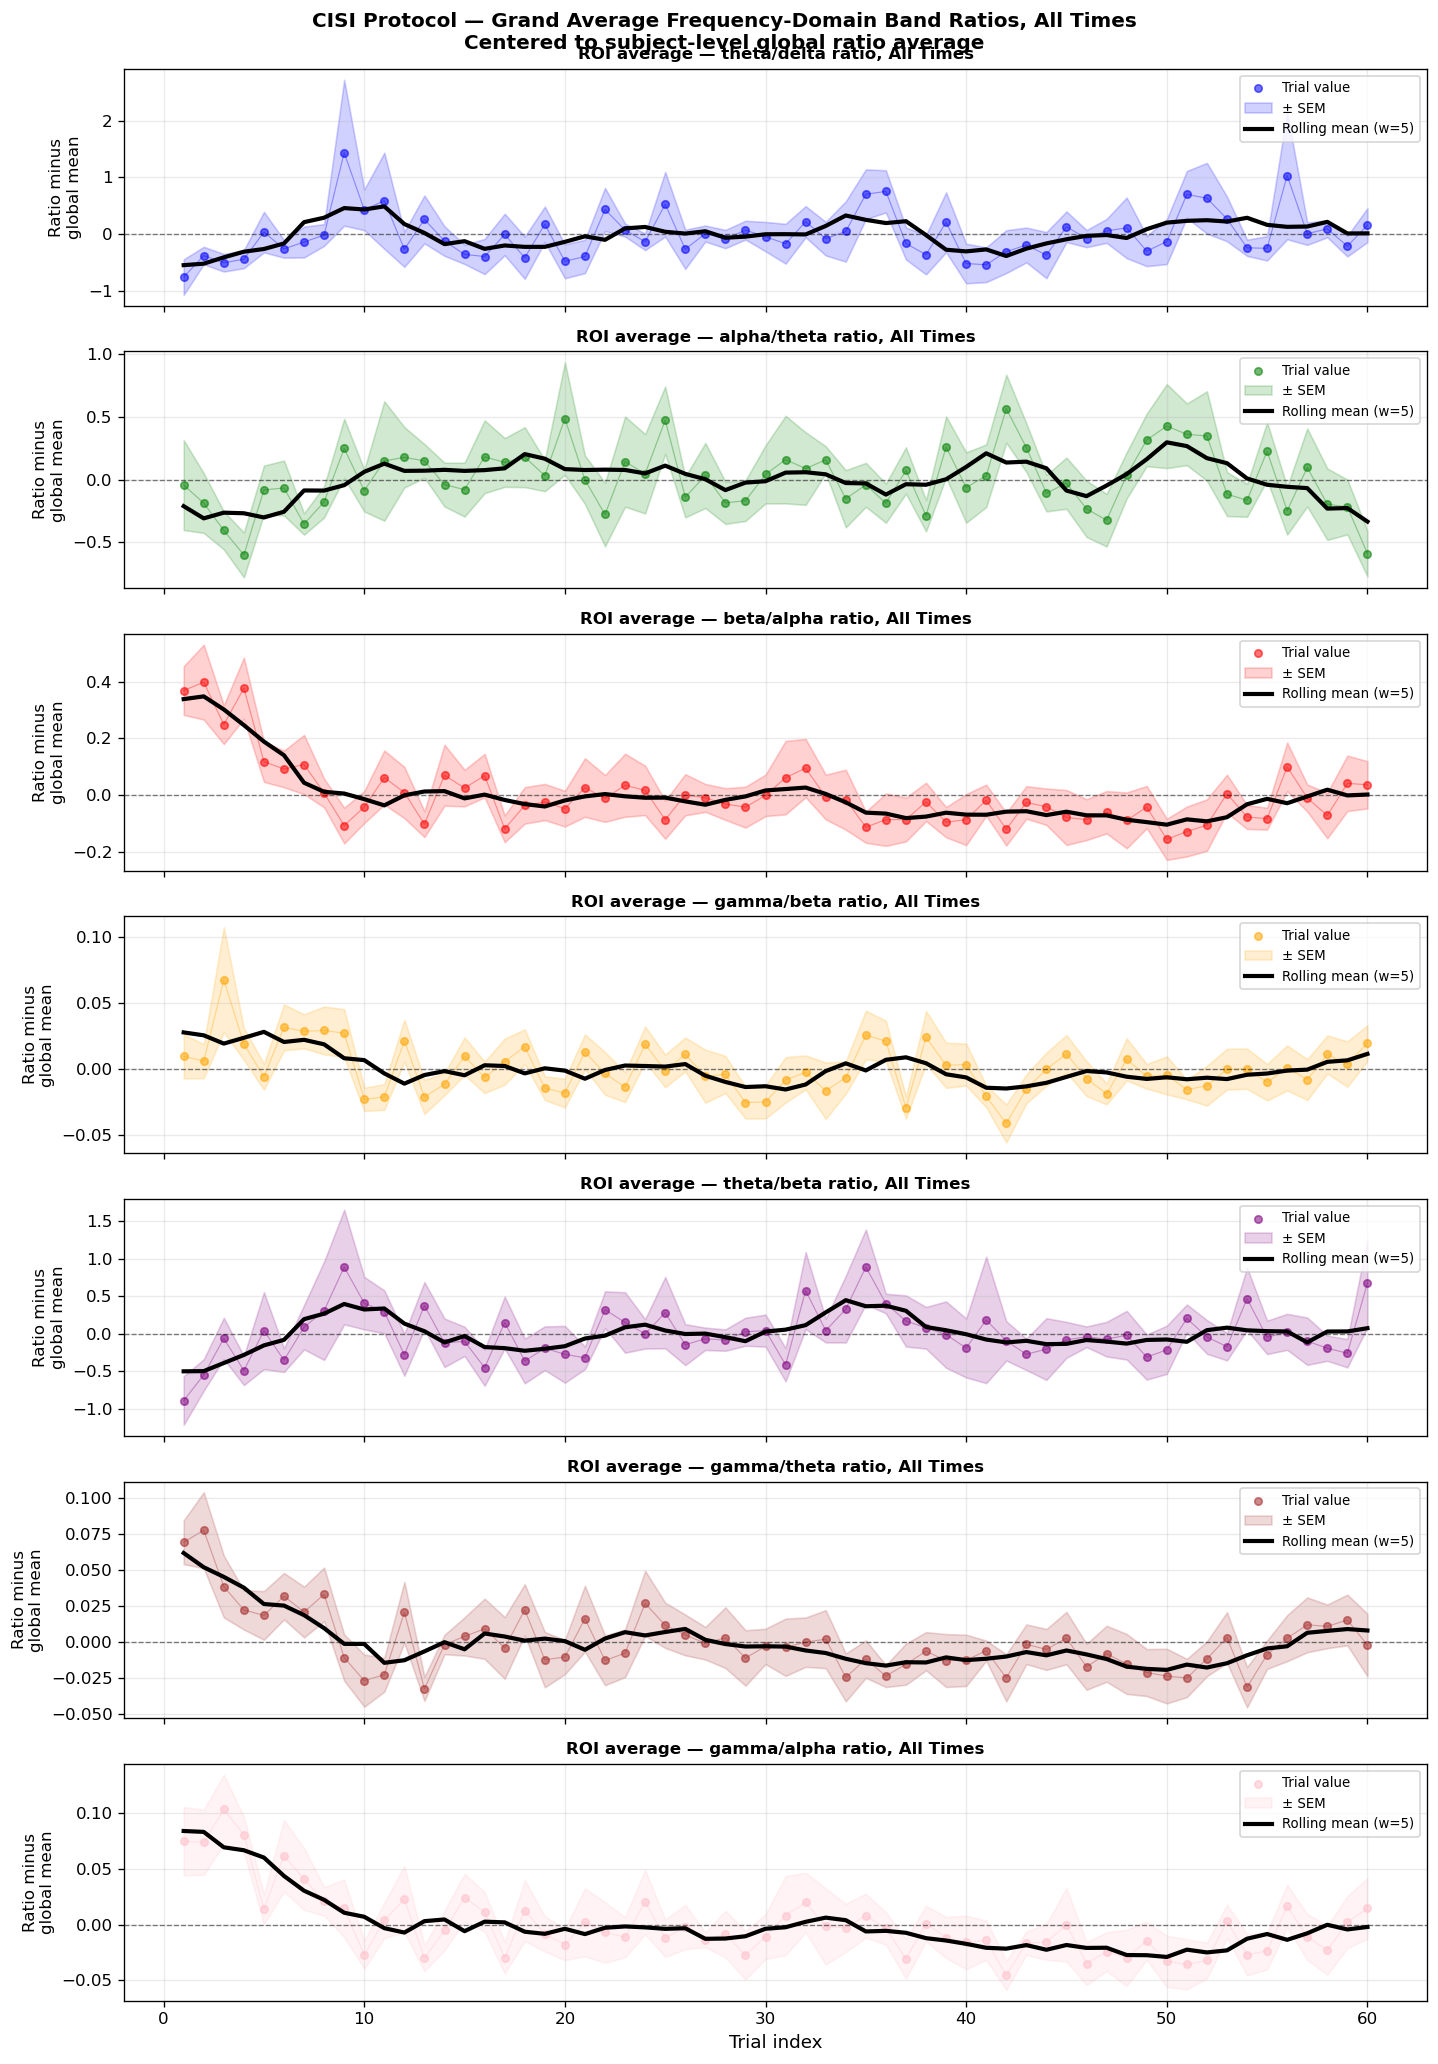

Figure saved: CISI_band_ratios_all_times_global_mean_centered.png


In [21]:
# Source: ZCISI_ratio.ipynb, cell 4

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="CISI_band_ratios_all_times_global_mean_centered.png"
)
